In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
path = "/content/Student Mental Health.csv"
df = pd.read_csv(path)
df

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
0,21,Male,Other,Undergraduate,Facebook,Networking,4.0,134,4.5,2.2,6.7,Medium,6.8
1,23,Female,Other,Graduate,LinkedIn,Education,1.6,73,7.0,2.4,8.6,Low,7.6
2,22,Male,Canada,Undergraduate,Instagram,Entertainment,4.6,166,4.0,1.8,6.7,Medium,7.0
3,18,Male,Other,High School,Snapchat,Entertainment,7.0,220,1.0,1.7,5.4,Very High,5.3
4,24,Female,Other,Graduate,Facebook,Networking,7.5,237,1.0,1.1,5.0,Very High,4.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,18,Female,Other,High School,YouTube,Education,1.9,89,6.1,2.2,7.9,Low,7.9
4996,18,Female,Other,High School,YouTube,Education,6.6,216,2.3,1.8,6.0,Very High,4.7
4997,19,Female,India,Undergraduate,LinkedIn,Education,3.8,151,5.4,1.4,7.5,Medium,7.0
4998,18,Male,Other,High School,Instagram,Entertainment,3.8,119,4.0,1.5,6.4,Medium,6.7


In [ ]:
df.describe()

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
count,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,20.82180,5.078460,171.452600,3.008420,1.751000,6.634580,6.230980
std,1.73662,1.653913,42.858254,1.637018,0.668398,1.221391,1.278701
min,18.00000,1.000000,62.000000,0.300000,-0.400000,3.600000,3.600000
25%,19.00000,3.800000,140.000000,1.500000,1.300000,5.600000,5.100000
50%,21.00000,5.000000,171.000000,2.800000,1.700000,6.600000,6.100000
75%,22.00000,6.300000,204.000000,4.200000,2.200000,7.500000,7.100000
max,24.00000,8.800000,273.000000,8.300000,4.100000,9.900000,9.400000


In [ ]:
df.columns

Index(['Age', 'Gender', 'Country', 'Academic_Level', 'Most_Used_Platform',
       'Purpose_Of_Use', 'Avg_Daily_Usage_Hours', 'Daily_Unlocks',
       'Study_Hours', 'Physical_Activity_Hours', 'Sleep_Hours_Per_Night',
       'Stress_Level', 'Mental_Health_Score'],
      dtype='object')

In [ ]:
df.sample(4)

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
2843,20,Female,Other,Undergraduate,Instagram,Entertainment,8.4,260,1.0,1.5,5.7,Very High,4.9
3029,20,Male,Other,Undergraduate,Twitter,News,2.7,114,4.9,1.9,8.4,Low,7.6
3182,20,Female,Other,Undergraduate,YouTube,Education,5.7,190,2.1,1.9,4.7,High,5.2
2632,22,Male,USA,Undergraduate,LinkedIn,Education,5.6,204,3.3,0.3,6.7,Medium,6.7


<Axes: ylabel='count'>

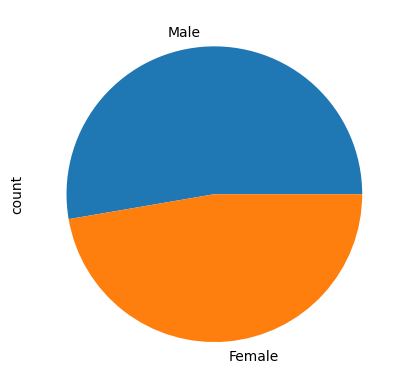

In [ ]:
df["Gender"].value_counts().plot(kind="pie")

In [ ]:
df["Country"].value_counts().reset_index().sort_values(by="Country")

,Country,count
33,Afghanistan,8
63,Albania,3
40,Andorra,5
46,Argentina,5
106,Armenia,1
...,...,...
32,Uzbekistan,8
65,Vatican City,3
87,Venezuela,2
45,Vietnam,5


In [ ]:
df["Academic_Level"].value_counts()

,count
Academic_Level,
Undergraduate,3632
Graduate,918
High School,450


In [ ]:
df["Most_Used_Platform"].value_counts()

,count
Most_Used_Platform,
Instagram,1130
TikTok,918
Facebook,719
LinkedIn,523
YouTube,491
Twitter,462
Snapchat,420
WhatsApp,175
LINE,50


In [ ]:
df["Purpose_Of_Use"].value_counts()

,count
Purpose_Of_Use,
Entertainment,2552
Education,1094
Networking,793
News,561


In [ ]:
df["Stress_Level"].value_counts()

,count
Stress_Level,
Very High,1621
High,1440
Medium,1295
Low,644


In [ ]:
df.groupby(['Gender', 'Stress_Level']).size()

Gender  Stress_Level
Female  High            720
        Low             301
        Medium          564
        Very High       780
Male    High            720
        Low             343
        Medium          731
        Very High       841
dtype: int64

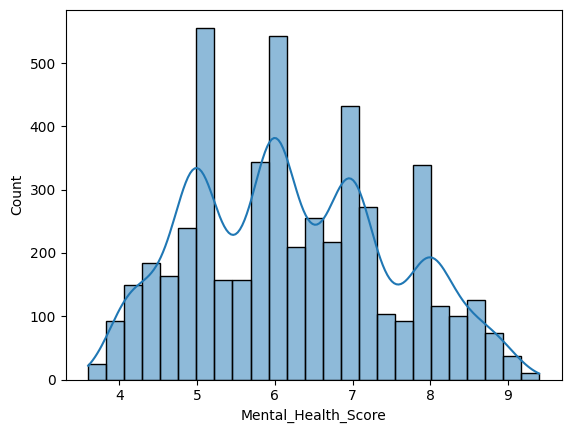

In [ ]:
sns.histplot(df["Mental_Health_Score"],kde=True);

<Axes: xlabel='Sleep_Hours_Per_Night', ylabel='Mental_Health_Score'>

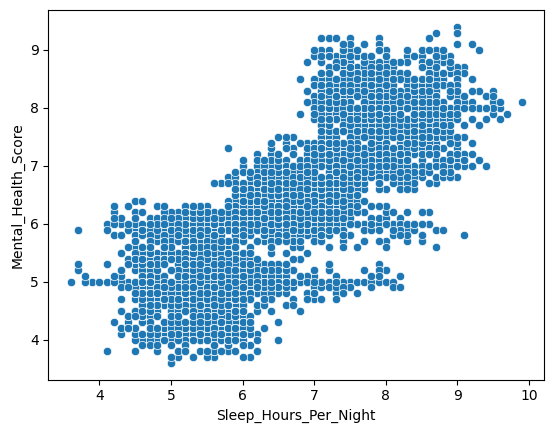

In [ ]:
sns.scatterplot(x="Sleep_Hours_Per_Night",y="Mental_Health_Score",data=df)

<Axes: >

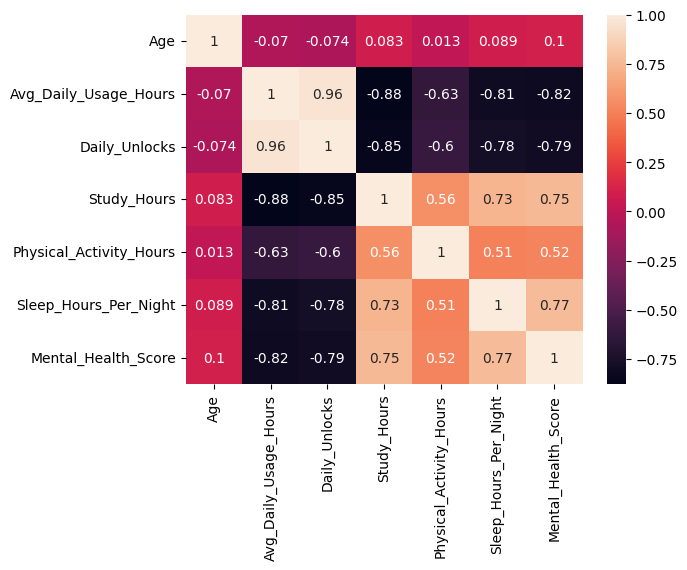

In [ ]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

### Converting negative or unrealitstic value to realistic value 0

In [ ]:
df["Physical_Activity_Hours"] = df["Physical_Activity_Hours"].clip(lower=0)

## Feature Engineering

**One meaningful engineered feature here:** grouping `Country`.

- `Country` has **111 unique values** in this dataset — one-hot encoding that directly would add 110+ mostly-empty columns, which hurts the model far more than it helps (this is called high cardinality).
- Dropping `Country` entirely throws away real signal — a student's country genuinely correlates with things like internet access, culture, and sleep norms.
- **The fix:** keep the top 10 most frequent countries as their own category, and bucket everything else into `"Other"`.

In [ ]:
top_countries = df["Country"].value_counts().index[:10].tolist()

In [ ]:
def group_countries(country):
  if country in top_countries:
    return country
  else:
    return "Other"

In [ ]:
df["Grouped_Country"] = df["Country"].apply(group_countries)

In [ ]:
df["Grouped_Country"].value_counts()

,count
Grouped_Country,
Other,3232
India,389
USA,355
Canada,230
Australia,198
UK,185
Germany,136
Mexico,94
Turkey,94


## Encoding

*how* each categorical column should be encoded — this decision matters more than the code.

- **`Stress_Level` → Ordinal Encoding.** Its categories have a real, meaningful order: Low < Medium < High < Very High. Score drops step by step as stress increases — encoding it as 0, 1, 2, 3 preserves that order for the model.
- **`Gender`, `Academic_Level`, `Most_Used_Platform`, `Purpose_Of_Use`, `Country_Grouped` → One-Hot Encoding.** These categories have **no natural order** — "Instagram" isn't "greater than" "LinkedIn". One-hot encoding creates a separate 0/1 column per category so the model doesn't accidentally assume a false ranking.

We'll implement both of these inside a single **`ColumnTransformer`** in the next step, rather than doing it manually column by column — that keeps preprocessing consistent and reusable.

## Train-Test Split

**Why we split:** we need data the model has never seen to honestly check how well it generalizes. If we evaluate on the same data we trained on, the model can just "memorize" the answers and look artificially good.

**Common ratios:** 80/20 or 70/30 are both standard. We'll use an 80/20 split here — with 5,000 rows, that still leaves 1,000 rows for a solid, reliable test.

We split **before** fitting any preprocessing — this is the single most common beginner mistake (called data leakage), and we'll avoid it by fitting everything only on the training set.

In [ ]:
df.columns

Index(['Age', 'Gender', 'Country', 'Academic_Level', 'Most_Used_Platform',
       'Purpose_Of_Use', 'Avg_Daily_Usage_Hours', 'Daily_Unlocks',
       'Study_Hours', 'Physical_Activity_Hours', 'Sleep_Hours_Per_Night',
       'Stress_Level', 'Mental_Health_Score', 'Grouped_country',
       'Grouped_Country'],
      dtype='object')

In [ ]:
from sklearn.model_selection import train_test_split
stud_hrs = ["Study_Hours"]

other_numeric_columns = ['Age','Avg_Daily_Usage_Hours','Daily_Unlocks','Physical_Activity_Hours',"Sleep_Hours_Per_Night"]
ordinal_col = ["Stress_Level"]
normal_col = ["Gender","Academic_Level","Most_Used_Platform",
              "Purpose_Of_Use","Grouped_country"]
feature_col = stud_hrs + other_numeric_columns + ordinal_col + normal_col


In [ ]:
X = df[feature_col]
y = df["Mental_Health_Score"]
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.20,random_state=42)

In [ ]:
X_train

,Study_Hours,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Gender,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Grouped_country
4227,1.4,23,5.6,171,1.8,6.8,High,Female,Graduate,Snapchat,Entertainment,Other
4676,1.4,19,7.1,208,1.2,5.0,Very High,Male,Undergraduate,TikTok,Entertainment,Other
800,2.1,20,6.0,189,3.0,5.8,Very High,Male,Undergraduate,Snapchat,Entertainment,Other
3671,0.7,19,8.7,259,1.4,4.7,Very High,Female,Undergraduate,LinkedIn,Education,Other
4193,2.1,21,7.3,239,1.0,4.9,Very High,Female,Undergraduate,YouTube,Education,Australia
...,...,...,...,...,...,...,...,...,...,...,...,...
4426,4.6,23,2.5,100,2.0,7.5,Medium,Female,Graduate,LinkedIn,Education,Other
466,1.9,18,7.4,220,0.9,5.8,Very High,Female,High School,YouTube,Education,Other
3092,0.9,19,7.4,236,0.4,4.7,Very High,Female,Undergraduate,Instagram,Entertainment,USA
3772,4.2,24,3.9,129,1.7,7.6,Low,Male,Graduate,LinkedIn,Education,Other


#### Preprocessing using ColumnTransformer

Our columns need **different treatment**:



*   FunctionTransformer ---- Applied to: Study_Hours
*   StandardScaler --- Applied to: Age, Sleep_Hours
*   Physical_Activity_Hours, Daily_Usage_Hours
*   OrdinalEncoder -- Applied to: Stress_Level



 This gets combined together inside the `ColumnTransformer`.

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer

skew_pipeline = Pipeline(steps=[
    ('log_transform', FunctionTransformer(np.log1p)),
    ('scale', StandardScaler())

])


plain_numeric_pipeline = Pipeline(steps=[
    ('scale',StandardScaler())
])


ordinal_pipeline = Pipeline(steps=[
    ('encode', OrdinalEncoder(categories=[['Low', 'Medium', 'High', 'Very High']]))
])


nominal_pipeline = Pipeline(steps=[
    ('encode', OneHotEncoder(handle_unknown="ignore"))
])



preprocessor = ColumnTransformer(transformers=[
    ("Skewed_Pipeline", skew_pipeline, skwewd_col),
    ("Plain_Numeric",plain_numeric_pipeline, other_numeric_cols ),
    ('Ordinal', ordinal_pipeline, ordinal_col),
    ('Normal', nominal_pipeline, normal_col)
])

## 11. Build a Pipeline

**Why Pipeline matters:** a `Pipeline` chains preprocessing and the model into a single object. Calling `.fit()` once does both steps in the correct order, and calling `.predict()` on brand-new raw data automatically applies the exact same preprocessing that was used during training — no risk of forgetting a step or applying it inconsistently.

**Why companies prefer this:** when this model gets deployed, the API doesn't need to know *anything* about scaling, encoding, or any data transformations — it just loads one saved pipeline object and calls `.predict()` on raw input. That's a huge reduction in what can go wrong in production.

We'll build two pipelines below — one per model.

## Model Building

We're building **two models** here Plain Linear Regression baseline and a Random Forest.

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

lr_pipeline.fit(X_train, y_train)
lr_preds       = lr_pipeline.predict(X_test)
lr_preds_train = lr_pipeline.predict(X_train)

lr_r2_testing  = r2_score(y_test, lr_preds)
lr_r2_training = r2_score(y_train, lr_preds_train)
lr_mae         = mean_absolute_error(y_test, lr_preds)

print(f"Accuracy of Training {lr_r2_training}")
print(f"Accuracy of Testing {lr_r2_testing}")
print(f'MAE {lr_mae}')

Accuracy of Training 0.722048518811711
Accuracy of Testing 0.7574878400384027
MAE 0.5078013784567164


### Random Forest (default settings)

Same preprocess, different model at the end — that's the entire point of building the pipeline once.